## Breast Cancer Classification using CNN (CancerNet)

## Objective
The Objective of this project is to build a deep learning model that classify breast cancerhistology imagesas benign or malignant using CNN 

## Loading Dataset paths and splitting the dataset

In [5]:
import os
INPUT_DATASET = r"E:\dataset\IDC_regular_ps50_idx5"
BASE_PATH = r"E:\datasets\idc"
TRAIN_PATH = os.path.sep.join([BASE_PATH, "training"])
VAL_PATH = os.path.sep.join([BASE_PATH, "validation"])
TEST_PATH = os.path.sep.join([BASE_PATH, "testing"])
TRAIN_SPLIT = 0.8
VAL_SPLIT = 0.1

## Loading and shuffling image paths

In [2]:
from imutils import paths
import random, shutil, os
originalPaths=list(paths.list_images(INPUT_DATASET))
random.seed(7)
random.shuffle(originalPaths)
index=int(len(originalPaths)*TRAIN_SPLIT)
trainPaths=originalPaths[:index]
testPaths=originalPaths[index:]
index=int(len(trainPaths)*VAL_SPLIT)
valPaths=trainPaths[:index]
trainPaths=trainPaths[index:]
datasets=[("training", trainPaths, TRAIN_PATH),
          ("validation", valPaths, VAL_PATH),
          ("testing", testPaths, TEST_PATH)
]

for (setType, originalPaths, basePath) in datasets:
    print(f'Building {setType} set')
    if not os.path.exists(basePath):
        print(f'Building directory {basePath}')
        os.makedirs(basePath)
    for path in originalPaths:
        file=path.split(os.path.sep)[-1]
        label=file[-5:-4]
        labelPath=os.path.sep.join([basePath,label])
        if not os.path.exists(labelPath):
            print(f'Building directory {labelPath}')
            os.makedirs(labelPath)
        newPath=os.path.sep.join([labelPath, file])
        shutil.copy2(path, newPath)
                    

Building training set
Building directory E:\datasets\idc\training
Building directory E:\datasets\idc\training\0
Building directory E:\datasets\idc\training\1
Building validation set
Building directory E:\datasets\idc\validation
Building directory E:\datasets\idc\validation\1
Building directory E:\datasets\idc\validation\0
Building testing set
Building directory E:\datasets\idc\testing
Building directory E:\datasets\idc\testing\1
Building directory E:\datasets\idc\testing\0


## CNN Architecture

In [6]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import backend as K

class CancerNet:
    def build(width, height, depth, classes):
        model = tf.keras.models.Sequential()
        shape = (height, width, depth)
        channelDim = -1

        if K.image_data_format() == "channels_first":
            shape = (depth, height, width)
            channelDim = 1

        model.add(tf.keras.layers.Conv2D(32, (3,3), activation="relu", input_shape=shape))
        model.add(tf.keras.layers.BatchNormalization(axis=channelDim))
        model.add(tf.keras.layers.MaxPool2D(pool_size=2))
        model.add(tf.keras.layers.Dropout(0.25))

        model.add(tf.keras.layers.Conv2D(64, (3,3), activation="relu"))
        model.add(tf.keras.layers.BatchNormalization(axis=channelDim))
        model.add(tf.keras.layers.Conv2D(64, (3,3), activation="relu"))
        model.add(tf.keras.layers.BatchNormalization(axis=channelDim))
        model.add(tf.keras.layers.MaxPool2D(pool_size=2))
        model.add(tf.keras.layers.Dropout(0.25))

        model.add(tf.keras.layers.Conv2D(128, (3,3), activation="relu"))
        model.add(tf.keras.layers.BatchNormalization(axis=channelDim))
        model.add(tf.keras.layers.MaxPool2D(pool_size=2))
        model.add(tf.keras.layers.Dropout(0.25))

        model.add(tf.keras.layers.GlobalAveragePooling2D())
        model.add(tf.keras.layers.Dense(128, activation="relu"))
        model.add(tf.keras.layers.BatchNormalization())
        model.add(tf.keras.layers.Dropout(0.5))

        model.add(tf.keras.layers.Dense(units=classes, activation="softmax"))

        return model
        

## Data Augmentation

In [7]:
import matplotlib
matplotlib.use("Agg")

train_datagen = ImageDataGenerator(rescale = 1./255,
                                   shear_range = 0.2,
                                   zoom_range = 0.2,
                                   horizontal_flip = True)
training_set = train_datagen.flow_from_directory(r"E:\datasets\idc\training",
                                                 target_size = (64, 64),
                                                 batch_size = 32,
                                                 class_mode = 'binary')


Found 199818 images belonging to 2 classes.


In [8]:
len(training_set)

6245

In [9]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import LearningRateScheduler
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from imutils import paths
import matplotlib.pyplot as plt
import numpy as np
import os

NUM_EPOCHS=15; INIT_LR=1e-2; BS=64

trainPaths=list(paths.list_images(TRAIN_PATH))
lenTrain=len(trainPaths)
lenVal=len(list(paths.list_images(VAL_PATH)))
lenTest=len(list(paths.list_images(TEST_PATH)))

trainLabels=[int(p.split(os.path.sep)[-2]) for p in trainPaths]
trainLabels=to_categorical(trainLabels)
classTotals=trainLabels.sum(axis=0)
classWeight=classTotals.max()/classTotals
classWeight = {0: classWeight[0], 1: classWeight[1]}

trainAug = ImageDataGenerator(
    rescale=1/255.0,
    rotation_range=20,
    zoom_range=0.05,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.05,
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode="nearest")

valAug=ImageDataGenerator(rescale=1 / 255.0)

trainGen = trainAug.flow_from_directory(
    TRAIN_PATH,
    class_mode="categorical",
    target_size=(32,32),
    color_mode="rgb",
    shuffle=True,
    batch_size=BS)

valGen = valAug.flow_from_directory(
    VAL_PATH,
    class_mode="categorical",
    target_size=(32,32),
    color_mode="rgb",
    shuffle=False,
    batch_size=BS)

testGen = valAug.flow_from_directory(
    TEST_PATH,
    class_mode="categorical",
    target_size=(32,32),
    color_mode="rgb",
    shuffle=False,
    batch_size=BS)

Found 199818 images belonging to 2 classes.
Found 22201 images belonging to 2 classes.
Found 55505 images belonging to 2 classes.


In [10]:
model=CancerNet.build(width=32,height=32,depth=3,classes=2)
model.compile(loss="categorical_crossentropy",optimizer="adam",metrics=["accuracy"])

E:\anaconda\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


##  Model Training

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint
checkpoint=ModelCheckpoint(
    "model_epoch_{epoch:02d}.keras",
    save_freq="epoch",
    verbose=1
)

In [ ]:
model=CancerNet.build(width=48,height=48,depth=3,classes=2)
model.compile(loss="binary_crossentropy",optimizer="adam",metrics=["accuracy"])

M=model.fit(trainGen, validation_data = valGen, epochs =NUM_EPOCHS , class_weight=classWeight,callbacks =[checkpoint])
           

E:\anaconda\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
3123/3123 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7918 - loss: 0.7000
Epoch 1: saving model to model_epoch_01.keras

Epoch 1: finished saving model to model_epoch_01.keras
3123/3123 ━━━━━━━━━━━━━━━━━━━━ 8870s 3s/step - accuracy: 0.8089 - loss: 0.6338 - val_accuracy: 0.7603 - val_loss: 0.4938
Epoch 2/15
3123/3123 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8218 - loss: 0.5846
Epoch 2: saving model to model_epoch_02.keras

Epoch 2: finished saving model to model_epoch_02.keras
3123/3123 ━━━━━━━━━━━━━━━━━━━━ 8783s 3s/step - accuracy: 0.8257 - loss: 0.5753 - val_accuracy: 0.8208 - val_loss: 0.4937
Epoch 3/15
2657/3123 ━━━━━━━━━━━━━━━━━━━━ 22:43 3s/step - accuracy: 0.8319 - loss: 0.5642

In [7]:
from tensorflow.keras.models import load_model
model=load_model("model_epoch_02.keras")

In [8]:
from tensorflow.keras.callbacks import ModelCheckpoint
checkpoint=ModelCheckpoint(
    "model_epoch_{epoch:02d}.keras",
    save_freq="epoch",
    verbose=1
)

In [ ]:
M=model.fit(trainGen, validation_data = valGen, epochs =NUM_EPOCHS ,initial_epoch=2, class_weight=classWeight,callbacks =[checkpoint])

Epoch 3/15
3123/3123 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8323 - loss: 0.5590
Epoch 3: saving model to model_epoch_03.keras

Epoch 3: finished saving model to model_epoch_03.keras
3123/3123 ━━━━━━━━━━━━━━━━━━━━ 11612s 4s/step - accuracy: 0.8336 - loss: 0.5557 - val_accuracy: 0.5574 - val_loss: 0.9555
Epoch 4/15
3123/3123 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8329 - loss: 0.5554
Epoch 4: saving model to model_epoch_04.keras

Epoch 4: finished saving model to model_epoch_04.keras
3123/3123 ━━━━━━━━━━━━━━━━━━━━ 9892s 3s/step - accuracy: 0.8350 - loss: 0.5480 - val_accuracy: 0.7530 - val_loss: 1.2686
Epoch 5/15
3123/3123 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8375 - loss: 0.5434
Epoch 5: saving model to model_epoch_05.keras

Epoch 5: finished saving model to model_epoch_05.keras
3123/3123 ━━━━━━━━━━━━━━━━━━━━ 9892s 3s/step - accuracy: 0.8370 - loss: 0.5414 - val_accuracy: 0.7140 - val_loss: 0.5870
Epoch 6/15
   4/3123 ━━━━━━━━━━━━━━━━━━━━ 2:41:56 3s/step - accuracy:

In [7]:
from tensorflow.keras.models import load_model
model=load_model("model_epoch_05.keras")

In [8]:
from tensorflow.keras.callbacks import ModelCheckpoint
checkpoint=ModelCheckpoint(
    "model_epoch_{epoch:02d}.keras",
    save_freq="epoch",
    verbose=1
)

In [ ]:
M=model.fit(
    trainGen,
    validation_data = valGen,
    epochs =NUM_EPOCHS,
    initial_epoch=5, 
    class_weight=classWeight,
    callbacks =[checkpoint])

Epoch 6/15
3123/3123 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8368 - loss: 0.5409
Epoch 6: saving model to model_epoch_06.keras

Epoch 6: finished saving model to model_epoch_06.keras
3123/3123 ━━━━━━━━━━━━━━━━━━━━ 10672s 3s/step - accuracy: 0.8390 - loss: 0.5359 - val_accuracy: 0.4919 - val_loss: 1.2995
Epoch 7/15
3123/3123 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8405 - loss: 0.5312
Epoch 7: saving model to model_epoch_07.keras

Epoch 7: finished saving model to model_epoch_07.keras
3123/3123 ━━━━━━━━━━━━━━━━━━━━ 9782s 3s/step - accuracy: 0.8402 - loss: 0.5317 - val_accuracy: 0.6254 - val_loss: 0.6638
Epoch 8/15
3123/3123 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8410 - loss: 0.5306
Epoch 8: saving model to model_epoch_08.keras

Epoch 8: finished saving model to model_epoch_08.keras
3123/3123 ━━━━━━━━━━━━━━━━━━━━ 9502s 3s/step - accuracy: 0.8416 - loss: 0.5284 - val_accuracy: 0.8592 - val_loss: 0.3277
Epoch 9/15


In [7]:
from tensorflow.keras.models import load_model
model=load_model("model_epoch_08.keras")

In [8]:
from tensorflow.keras.callbacks import ModelCheckpoint
checkpoint=ModelCheckpoint(
    "model_epoch_{epoch:02d}.keras",
    save_freq="epoch",
    verbose=1
)

In [ ]:
M=model.fit(trainGen, validation_data = valGen, epochs =NUM_EPOCHS ,initial_epoch=8, class_weight=classWeight,callbacks =[checkpoint])

Epoch 9/15
3123/3123 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8431 - loss: 0.5237
Epoch 9: saving model to model_epoch_09.keras

Epoch 9: finished saving model to model_epoch_09.keras
3123/3123 ━━━━━━━━━━━━━━━━━━━━ 10650s 3s/step - accuracy: 0.8430 - loss: 0.5245 - val_accuracy: 0.8129 - val_loss: 0.6649
Epoch 10/15
3123/3123 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8409 - loss: 0.5247
Epoch 10: saving model to model_epoch_10.keras

Epoch 10: finished saving model to model_epoch_10.keras
3123/3123 ━━━━━━━━━━━━━━━━━━━━ 10563s 3s/step - accuracy: 0.8420 - loss: 0.5238 - val_accuracy: 0.8128 - val_loss: 0.4193
Epoch 11/15


In [7]:
from tensorflow.keras.models import load_model
model=load_model("model_epoch_10.keras")

In [8]:
from tensorflow.keras.callbacks import ModelCheckpoint
checkpoint=ModelCheckpoint(
    "model_epoch_{epoch:02d}.keras",
    save_freq="epoch",
    verbose=1
)

In [9]:
M=model.fit(trainGen, validation_data = valGen, epochs =NUM_EPOCHS ,initial_epoch=10, class_weight=classWeight,callbacks =[checkpoint])

Epoch 11/15
3123/3123 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8424 - loss: 0.5222
Epoch 11: saving model to model_epoch_11.keras

Epoch 11: finished saving model to model_epoch_11.keras
3123/3123 ━━━━━━━━━━━━━━━━━━━━ 9307s 3s/step - accuracy: 0.8424 - loss: 0.5216 - val_accuracy: 0.8596 - val_loss: 0.3595
Epoch 12/15
3123/3123 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8439 - loss: 0.5225
Epoch 12: saving model to model_epoch_12.keras

Epoch 12: finished saving model to model_epoch_12.keras
3123/3123 ━━━━━━━━━━━━━━━━━━━━ 8703s 3s/step - accuracy: 0.8447 - loss: 0.5182 - val_accuracy: 0.8554 - val_loss: 0.3601
Epoch 13/15
3123/3123 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8435 - loss: 0.5161
Epoch 13: saving model to model_epoch_13.keras

Epoch 13: finished saving model to model_epoch_13.keras
3123/3123 ━━━━━━━━━━━━━━━━━━━━ 8632s 3s/step - accuracy: 0.8442 - loss: 0.5163 - val_accuracy: 0.8064 - val_loss: 0.4463
Epoch 14/15
3123/3123 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accur

## Model Evaluation

In [12]:
print("Now evaluating the model")
testGen.reset()
pred_indices=model.predict(testGen,steps=(lenTest//BS)+1)

pred_indices=np.argmax(pred_indices,axis=1)

print(classification_report(testGen.classes, pred_indices, target_names=testGen.class_indices.keys()))

cm=confusion_matrix(testGen.classes,pred_indices)
total=sum(sum(cm))
accuracy=(cm[0,0]+cm[1,1])/total
specificity=cm[0,0]/(cm[0,0]+cm[0,1])
sensitivity=cm[1,1]/(cm[1,1]+cm[1,0])
print(cm)
print(f'Accuracy: {accuracy}')
print(f'Specificity: {specificity}')
print(f'Sensitivity: {sensitivity}')



Now evaluating the model
868/868 ━━━━━━━━━━━━━━━━━━━━ 1814s 2s/step


E:\anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
E:\anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
E:\anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


              precision    recall  f1-score   support

           0       0.72      1.00      0.83     39736
           1       0.00      0.00      0.00     15769

    accuracy                           0.72     55505
   macro avg       0.36      0.50      0.42     55505
weighted avg       0.51      0.72      0.60     55505

[[39736     0]
 [15769     0]]
Accuracy: 0.7158994685163499
Specificity: 1.0
Sensitivity: 0.0


## Training Graphs

In [13]:
import matplotlib.pyplot as plt
import numpy as np

epochs = np.arange(1,16)

train_acc = [0.7918,0.8218,0.8323,0.8350,0.8375,0.8368,0.8405,0.8416,0.8431,0.8420,0.8424,0.8439,0.8435,0.8470,0.8451]
val_acc = [0.7603,0.8208,0.5574,0.7530,0.7140,0.4919,0.6254,0.8592,0.8129,0.8128,0.8596,0.8554,0.8064,0.8449,0.8464]
train_loss = [0.7000,0.5846,0.5590,0.5480,0.5434,0.5409,0.5312,0.5284,0.5237,0.5238,0.5222,0.5225,0.5161,0.5129,0.5132]
val_loss = [0.4938,0.4937,0.9555,1.2686,0.3870,1.1995,0.6638,0.3277,0.6649,0.4193,0.3595,0.3601,0.4463,0.3752,0.3581]

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(epochs, train_acc, label="Train Accuracy")
plt.plot(epochs, val_acc, label="Validation Accuracy")
plt.title("Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs, train_loss, label="Train Loss")
plt.plot(epochs, val_loss, label="Validation Loss")
plt.title("Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()



In [14]:
plt.savefig("training_results.png", dpi=300)

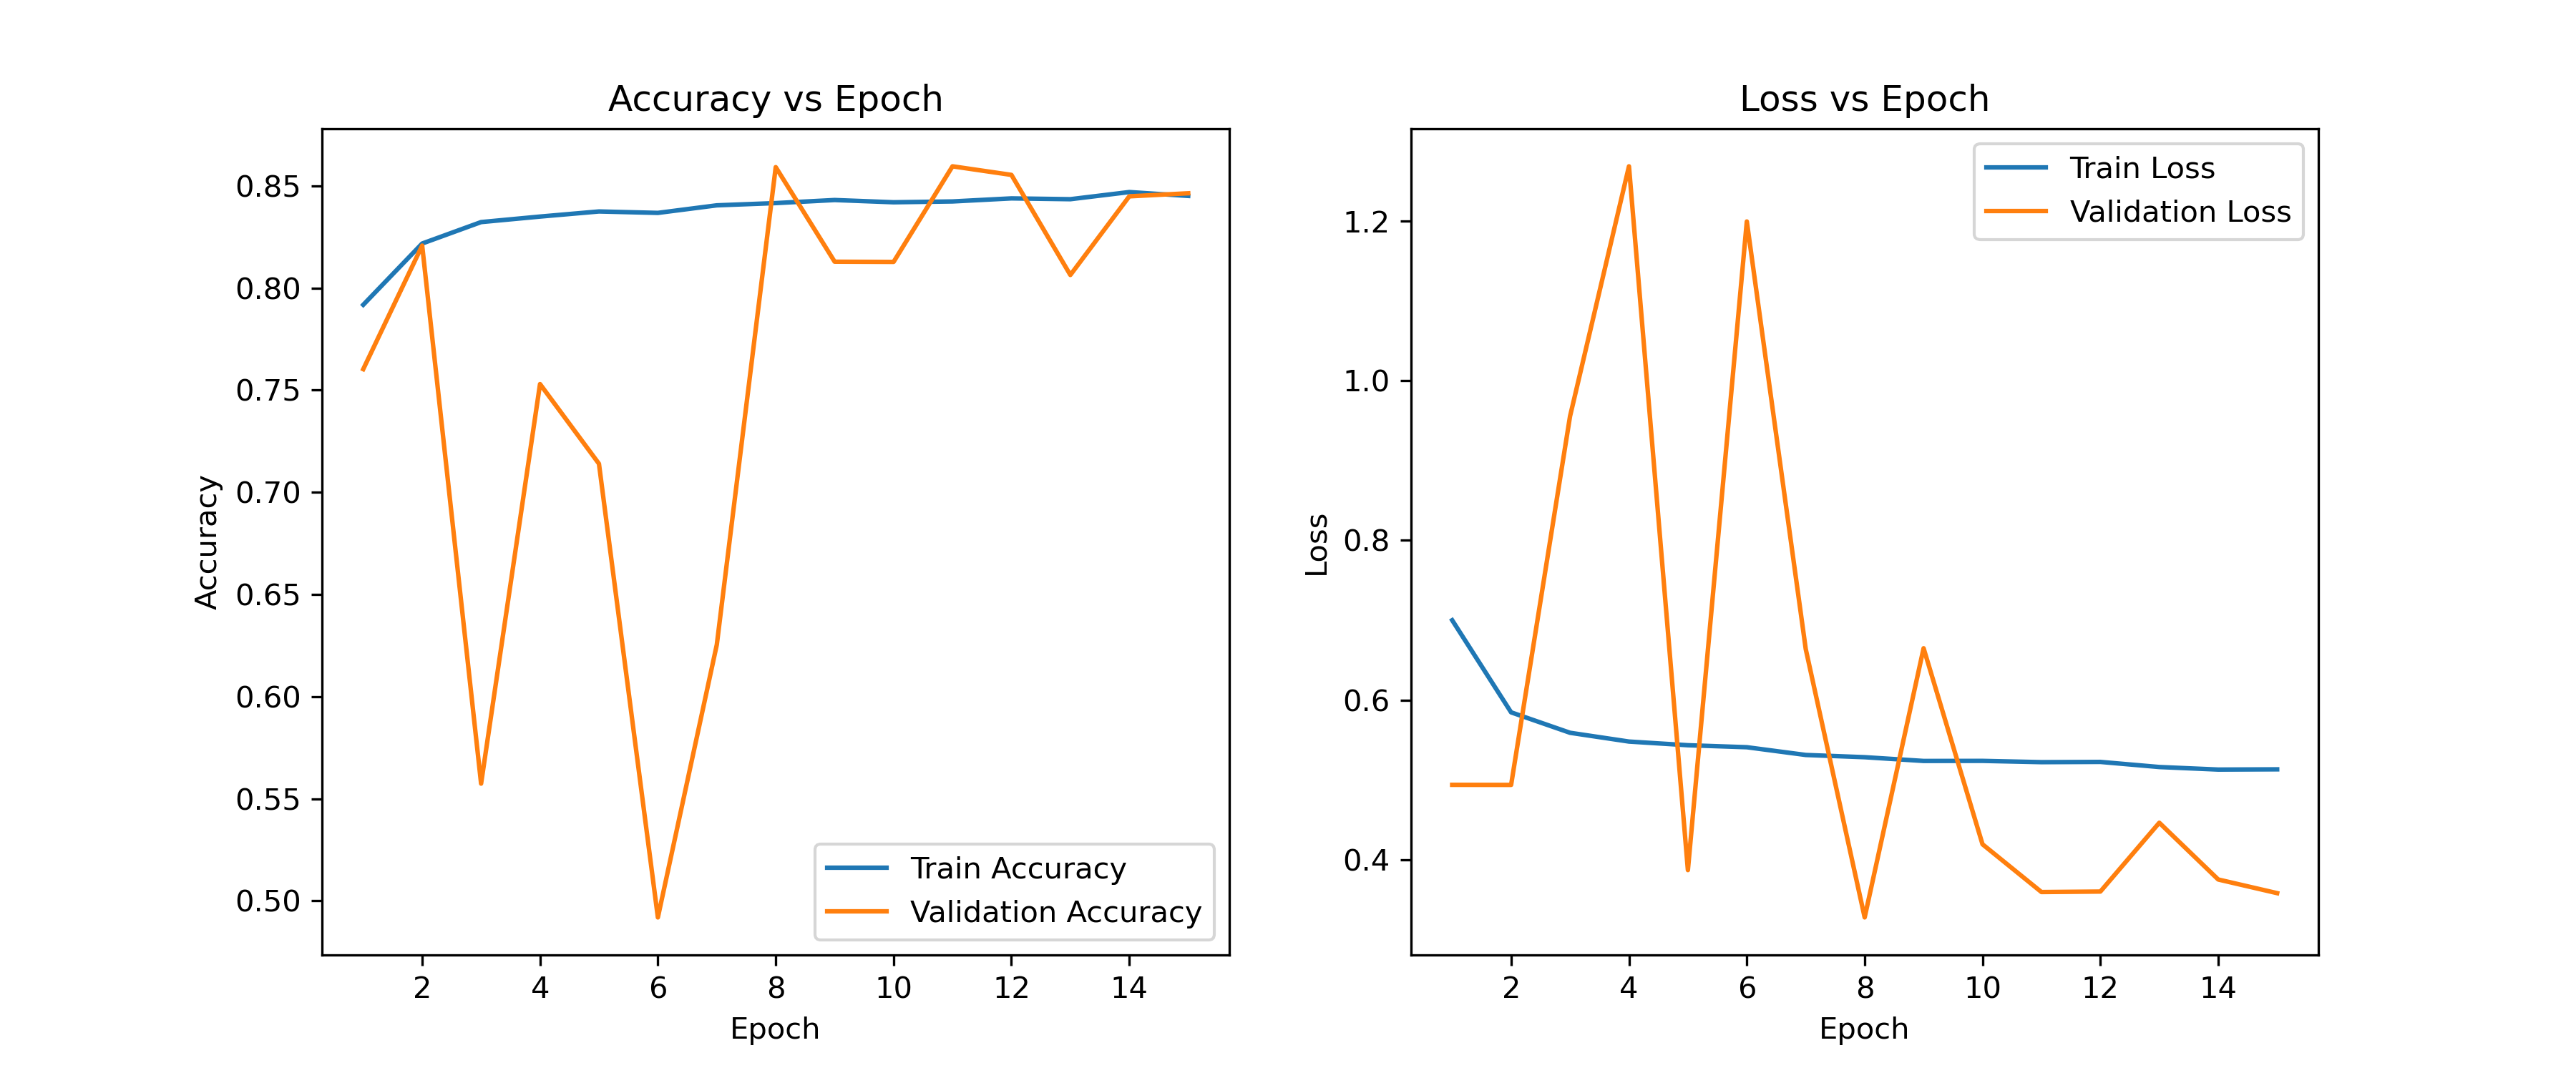

In [20]:
from IPython.display import Image
Image("training_results.png")

## Confusion Matrix

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(testGen.classes, pred_indices)

plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=testGen.class_indices.keys(),
            yticklabels=testGen.class_indices.keys())

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")



Text(0.5, 1.0, 'Confusion Matrix')

In [16]:
plt.savefig("confusion_matrix.png", dpi=300)

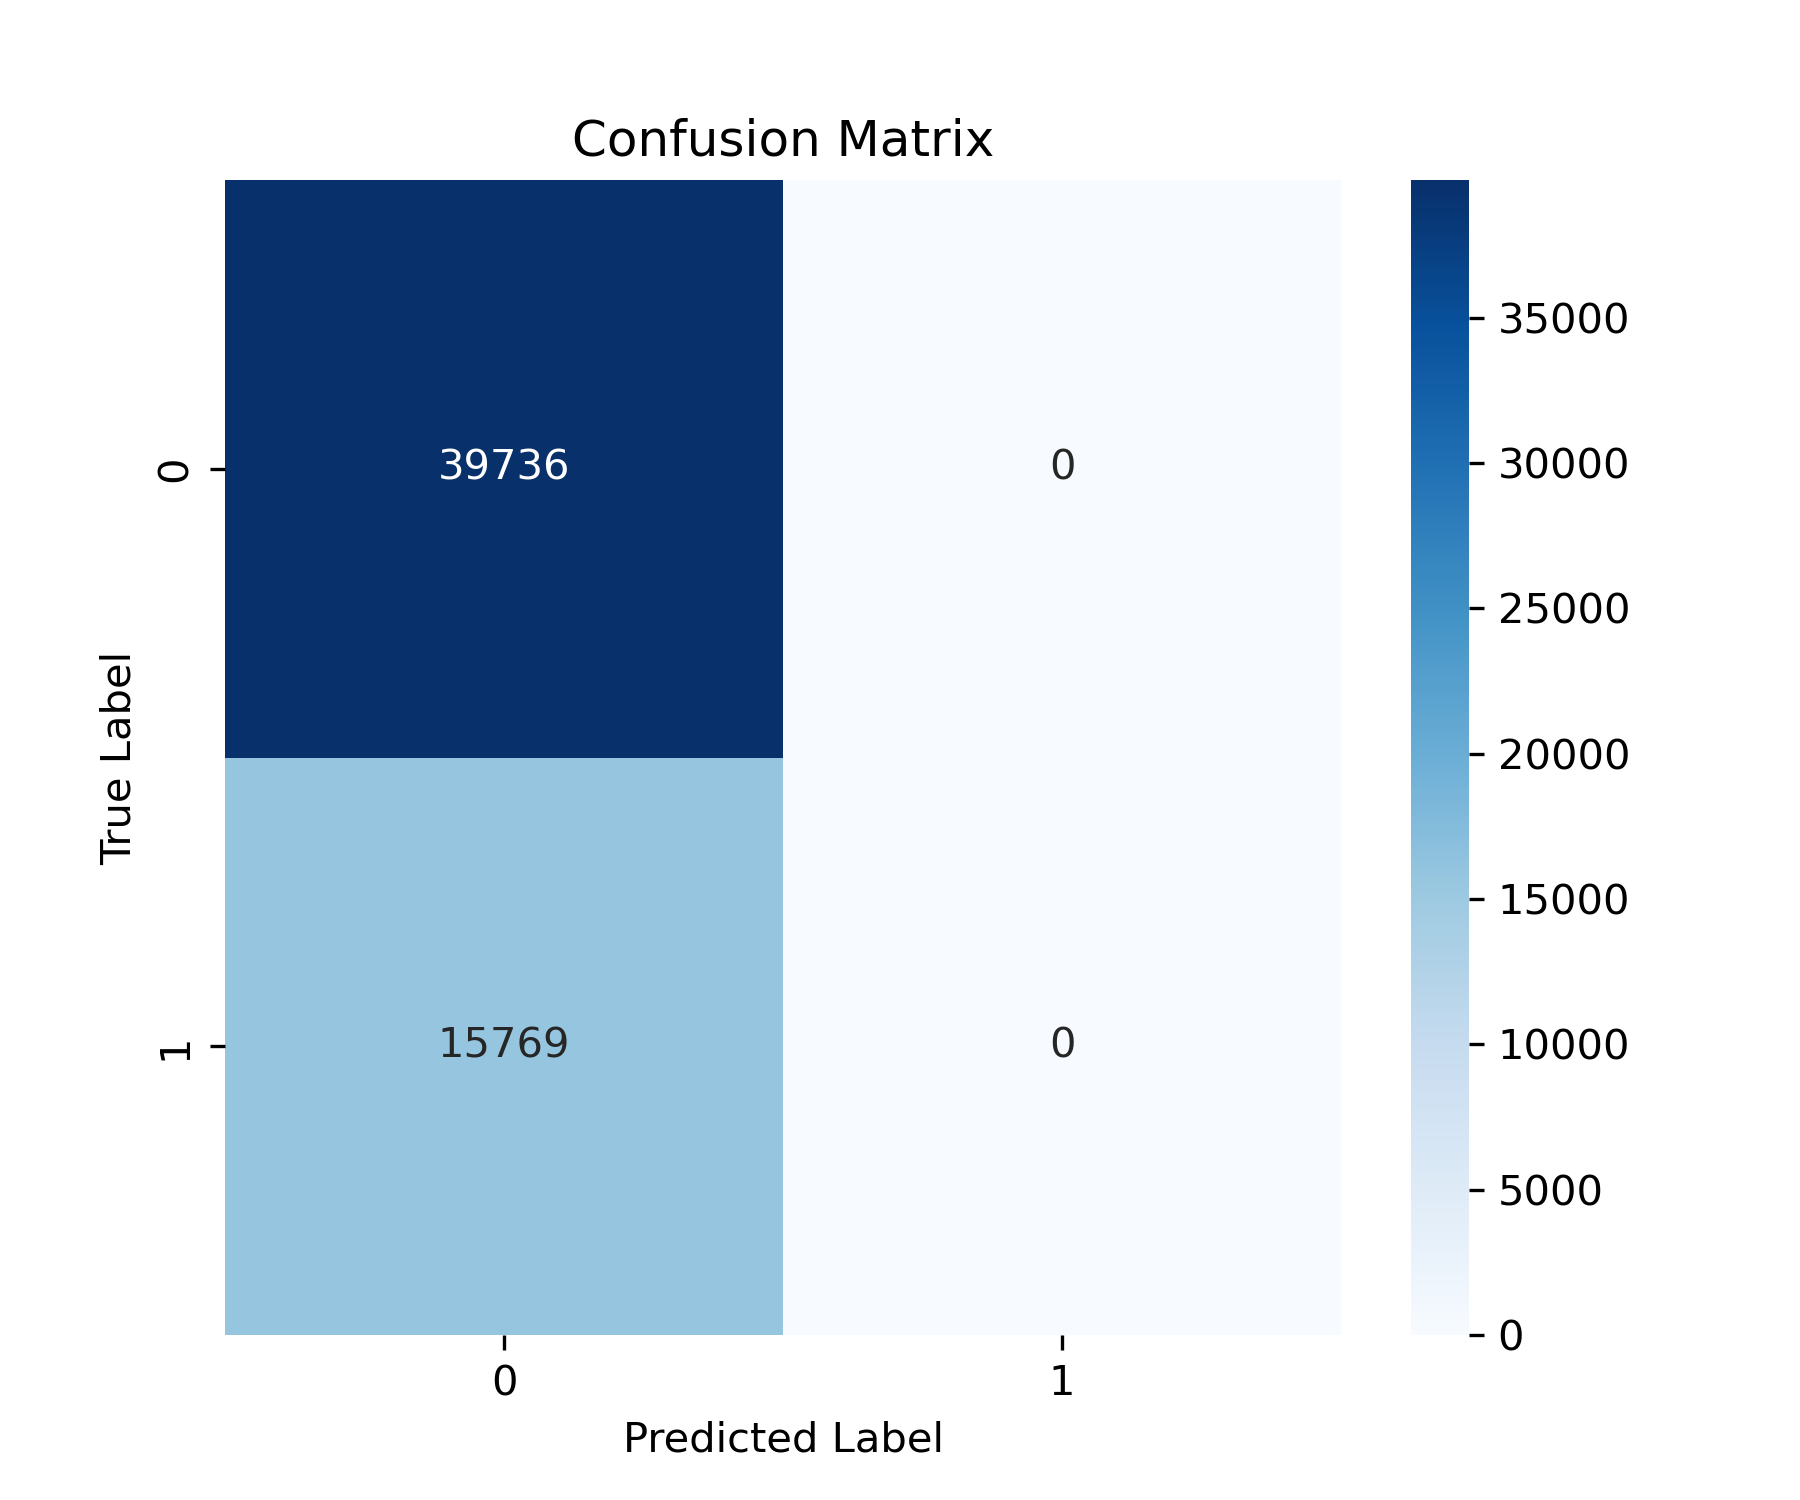

In [19]:
from IPython.display import Image
Image("confusion_matrix.png")

## ROC Curve

In [17]:
from sklearn.metrics import roc_curve, auc

pred_prob = model.predict(testGen)

fpr, tpr, threshold = roc_curve(testGen.classes, pred_prob[:,1])
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0,1],[0,1],'r--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")



868/868 ━━━━━━━━━━━━━━━━━━━━ 2251s 3s/step


In [18]:
plt.savefig("roc_curve.png", dpi=300)

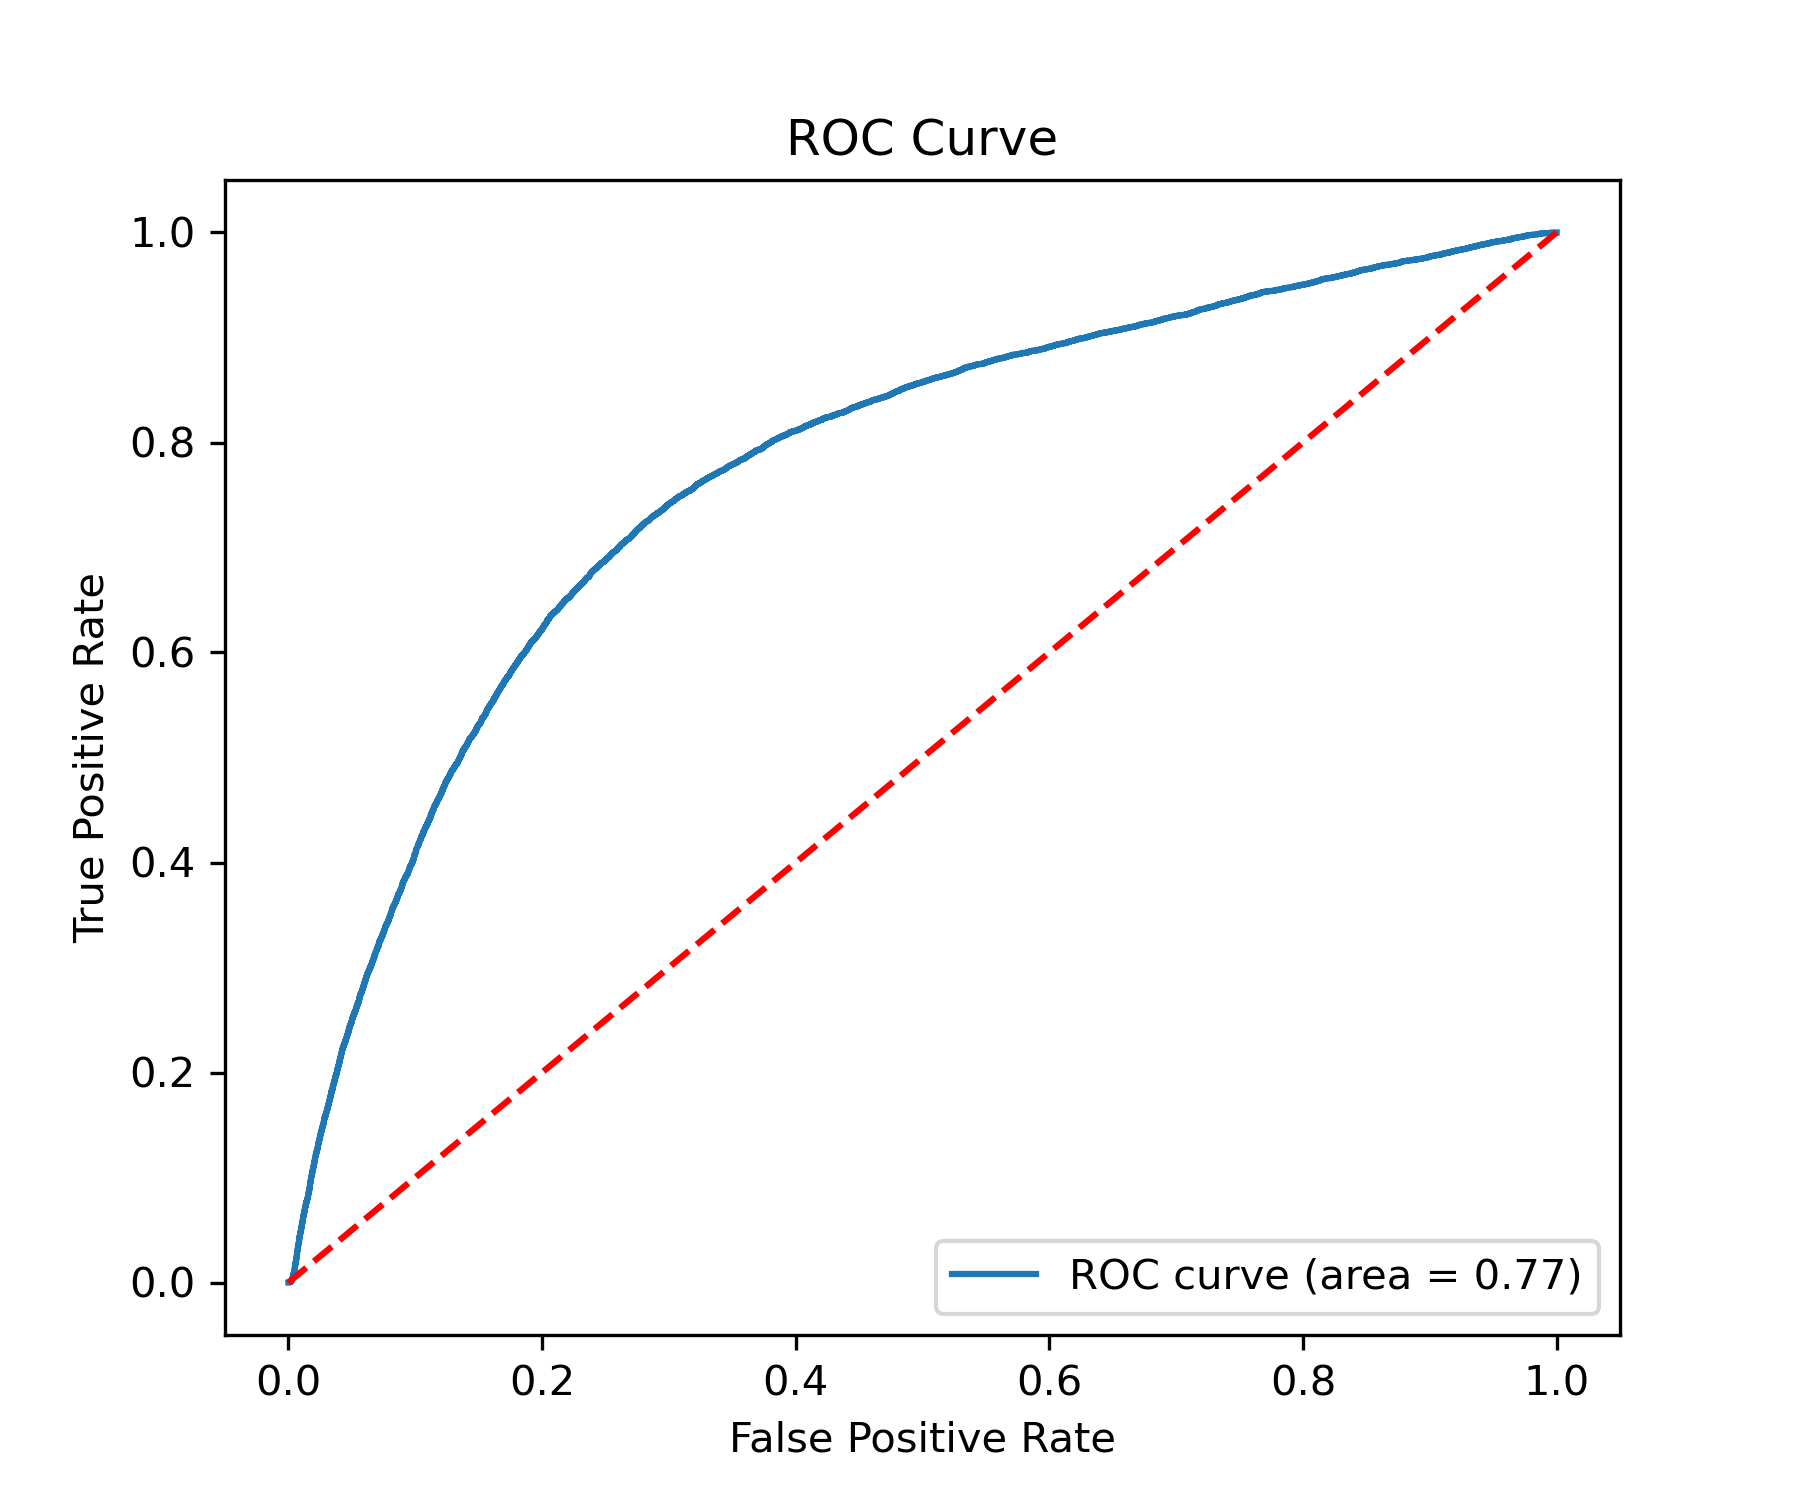

In [21]:
from IPython.display import Image
Image("roc_curve.png")